In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
try:
   df=pd.read_csv('/content/movie_titles (1).csv')
except UnicodeDecodeError:
       df=pd.read_csv('/content/movie_titles (1).csv',encoding='latin-1',header=None,names=["ID", "Rating","Genre","Movie_Name"],usecols = [0,1,2,3])


In [ ]:
df

,ID,Rating,Genre,Movie_Name
0,1,2003.0,Dinosaur Planet,NaN
1,2,2004.0,Isle of Man TT 2004 Review,NaN
2,3,1997.0,Character,NaN
3,4,1994.0,Paula Abdul's Get Up & Dance,NaN
4,5,2004.0,The Rise and Fall of ECW,NaN
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,NaN
17766,17767,2004.0,Fidel Castro: American Experience,NaN
17767,17768,2000.0,Epoch,NaN
17768,17769,2003.0,The Company,NaN


In [ ]:
from sklearn.decomposition import TruncatedSVD

In [ ]:
user_movie_matrix = df.pivot_table(
    index='ID',
    columns='Movie_Name',
    values='Rating'
).fillna(0)


In [ ]:
svd = TruncatedSVD(n_components=50, random_state=42)

latent_matrix = svd.fit_transform(user_movie_matrix)


In [ ]:
predicted_ratings = np.dot(
    latent_matrix,
    svd.components_
)

predicted_df = pd.DataFrame(
    predicted_ratings,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)


In [ ]:
def recommend_movies(user_id, n=5):
    user_predictions = predicted_df.loc[user_id]
    watched_movies = user_movie_matrix.loc[user_id]

    recommendations = user_predictions[watched_movies == 0] \
                        .sort_values(ascending=False) \
                        .head(n)

    return recommendations


In [ ]:
def recommend_with_titles(user_id, n=5):
    recs = recommend_movies(user_id, n)
    return df[df['Movie_Name'].isin(recs.index)]

In [ ]:
recommend_with_titles(user_id=72, n=5)

,ID,Rating,Genre,Movie_Name
3590,3591,2003.0,Be Good,Smile Pretty
8687,8688,1986.0,Manon of the Spring (Jean de Florette,Part II)
8689,8690,2003.0,Ashtanga,NY
10222,10223,2004.0,Cheating Death,Stealing Life: The Eddie Guerrero Story
15763,15764,2003.0,Legally Blonde 2: Red,White & Blonde


Find the Most Popular and Most Liked Genres

In [ ]:
popular_genre = df.groupby('Genre')['Rating'] \
                    .count() \
                    .sort_values(ascending=False)

print("Most Popular Genres:")
print(popular_genre)

Most Popular Genres:
Genre
Dr. Quinn                                      6
The Hunchback of Notre Dame                    6
I                                              6
Earth                                          5
Oliver Twist                                   5
                                              ..
Hote Hote Pyaar Ho Gaya                        0
Eros Dance Dhamaka                             0
Ancient Civilizations: Athens and Greece       0
Ancient Civilizations: Land of the Pharaohs    0
Ancient Civilizations: Rome and Pompeii        0
Name: Rating, Length: 17297, dtype: int64


Most Liked Genre (Highest Average Rating)

In [ ]:
liked_genre = df.groupby('Genre')['Rating'] \
                 .mean() \
                 .sort_values(ascending=False)

print("\nMost Liked Genres:")
print(liked_genre)



Most Liked Genres:
Genre
Rugrats All Grown Up: Dude                       2005.0
Mermaid Forest                                   2005.0
The Divine Bette Midler                          2005.0
The Dream of Sparrows: Iraq Eye Group: Vol. 1    2005.0
Le Portrait de Petite Cossette                   2005.0
                                                  ...  
Ancient Civilizations: Rome and Pompeii             NaN
Eros Dance Dhamaka                                  NaN
Hote Hote Pyaar Ho Gaya                             NaN
Jimmy Hollywood                                     NaN
Roti Kapada Aur Makaan                              NaN
Name: Rating, Length: 17297, dtype: float64


Best Suited Movie for Each User in Every Genre

In [ ]:
# Highest rated movie by each user per genre
best_movie_per_genre = df.sort_values(
    ['ID', 'Genre', 'Rating'],
    ascending=[True, True, False]
).groupby(['ID', 'Genre']).first()

print(best_movie_per_genre[['Movie_Name', 'Rating']])


                                                         Movie_Name  Rating
ID    Genre                                                                
1     Dinosaur Planet                                          None  2003.0
2     Isle of Man TT 2004 Review                               None  2004.0
3     Character                                                None  1997.0
4     Paula Abdul's Get Up & Dance                             None  1994.0
5     The Rise and Fall of ECW                                 None  2004.0
...                                                             ...     ...
17766 Where the Wild Things Are and Other Maurice Sen...       None  2002.0
17767 Fidel Castro: American Experience                        None  2004.0
17768 Epoch                                                    None  2000.0
17769 The Company                                              None  2003.0
17770 Alien Hunter                                             None  2003.0

[17770 rows

Best and Worst Rated Genres Based on User Ratings

In [ ]:
genre_rating = df.groupby('Genre')['Rating'].mean()

best_genre = genre_rating.idxmax()
worst_genre = genre_rating.idxmin()

print("Best Rated Genre:", best_genre)
print("Worst Rated Genre:", worst_genre)


Best Rated Genre: 11:14
Worst Rated Genre: Lumiere Brothers' First Films


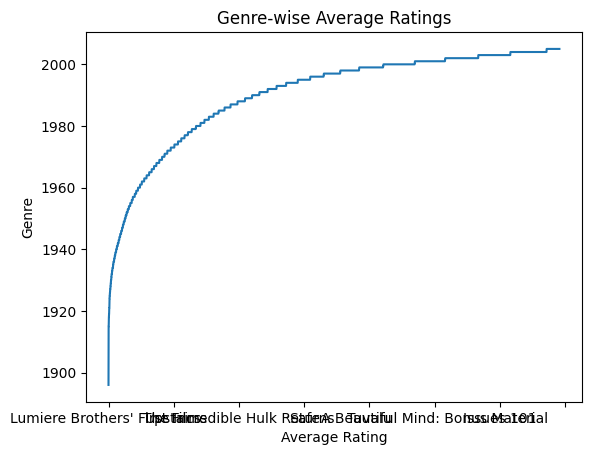

In [ ]:
import matplotlib.pyplot as plt

genre_rating.sort_values().plot(kind='line')
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Genre-wise Average Ratings")
plt.show()